# Supermarket Sales Data Analysis

## Project Overview
This project analyzes supermarket sales data using Python, Pandas, Matplotlib, Seaborn, and SQL to identify sales trends, customer behavior, product performance, and branch-level performance.

## 1. Data Understanding & Data Quality

In [81]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import sqlite3

df = pd.read_csv("supermarket_sales.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [82]:
df.shape

(1000, 17)

In [83]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'Cost of goods sold', 'Gross margin percentage',
       'Gross income', 'Customer stratification rating'],
      dtype='object')

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Invoice ID                      1000 non-null   object 
 1   Branch                          1000 non-null   object 
 2   City                            1000 non-null   object 
 3   Customer type                   1000 non-null   object 
 4   Gender                          1000 non-null   object 
 5   Product line                    1000 non-null   object 
 6   Unit price                      1000 non-null   float64
 7   Quantity                        1000 non-null   int64  
 8   Tax 5%                          1000 non-null   float64
 9   Total                           1000 non-null   float64
 10  Date                            1000 non-null   object 
 11  Time                            1000 non-null   object 
 12  Payment                         100

In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df.isnull().sum()

Invoice ID                        0
Branch                            0
City                              0
Customer type                     0
Gender                            0
Product line                      0
Unit price                        0
Quantity                          0
Tax 5%                            0
Total                             0
Date                              0
Time                              0
Payment                           0
Cost of goods sold                0
Gross margin percentage           0
Gross income                      0
Customer stratification rating    0
dtype: int64

In [87]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [88]:
# converting date and time  to datetime 

df['Date'] = pd.to_datetime(df['Date'])

df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time

# now check datatype
df[['Date', 'Time']].dtypes

Date    datetime64[ns]
Time            object
dtype: object

In [89]:
df['Months'] = df['Date'].dt.month
df['Month_name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()

In [90]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating,Months,Month_name,Day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,1,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6,3,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,3,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,1,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2,February,Friday


## 2. Exploratory Data Analysis

In [91]:
# Exploratory Data Analysis 

total_sales = df['Total'].sum()
total_orders = df['Invoice ID'].nunique()
total_quantity = df['Quantity'].sum()
total_profit = df['Gross income'].sum()
avg_order_values = df['Total'].mean()


print("Total Sales : ", round(total_sales, 2))
print("Total Orders : ", total_orders)
print("Total Quantity Sold : ", total_quantity)
print("Total Gross Income : ", round(total_profit, 2))
print("Average Order Value : ", round(avg_order_values, 2))

Total Sales :  322966.75
Total Orders :  1000
Total Quantity Sold :  5510
Total Gross Income :  15379.37
Average Order Value :  322.97


In [92]:
sales_by_category = df.groupby('Product line')['Total'].sum().sort_values(ascending=False)
print(sales_by_category)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64


## 3. Data Visualization

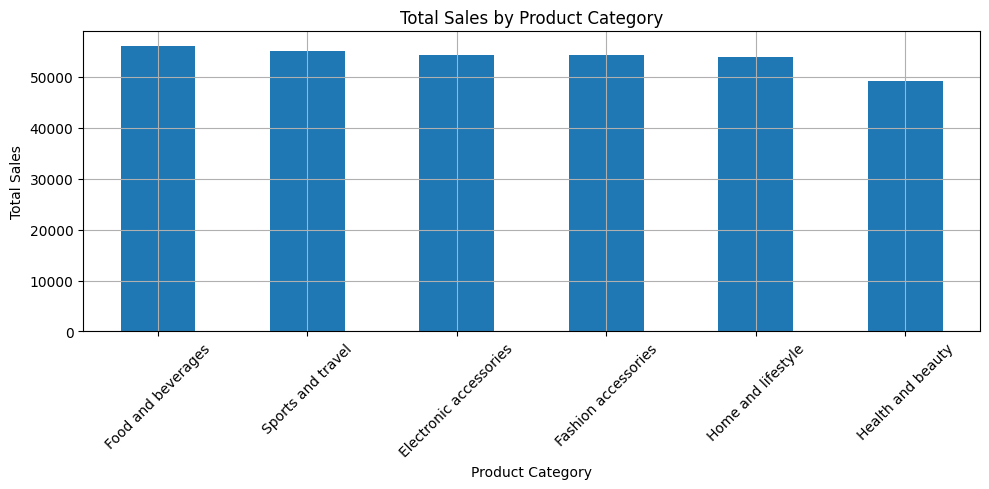

In [93]:
# visualization

plt.figure(figsize=(10, 5))

sales_by_category.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [94]:
# Which month generated the highest sales?

monthly_sales = df.groupby(['Months', 'Month_name'])['Total'].sum().reset_index()

monthly_sales = monthly_sales.sort_values('Months')

monthly_sales

,Months,Month_name,Total
0,1,January,116291.868
1,2,February,97219.374
2,3,March,109455.507


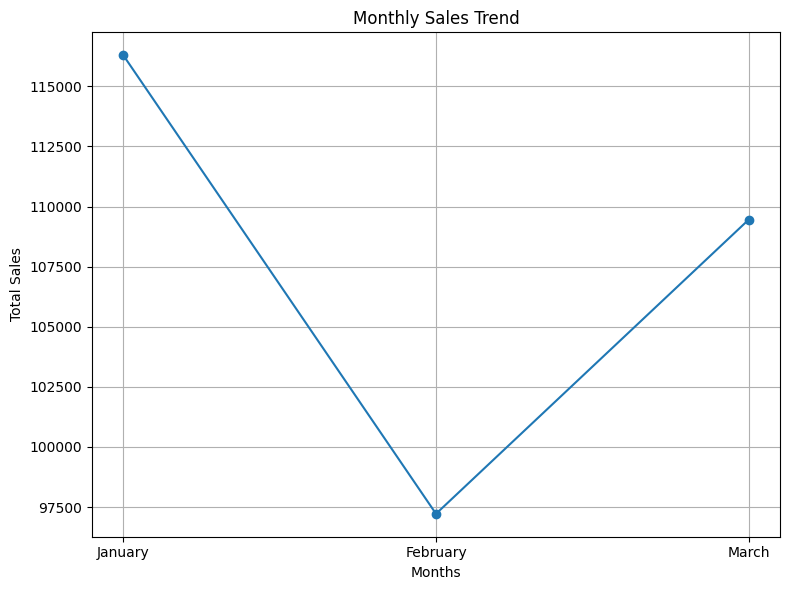

In [95]:
plt.figure(figsize=(8, 6))

plt.plot(
    monthly_sales['Month_name'],
    monthly_sales['Total'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.grid()
plt.tight_layout()
plt.show()

In [96]:
# Which supermarket branch performs best?

branch_sales = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)
print(branch_sales)

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64


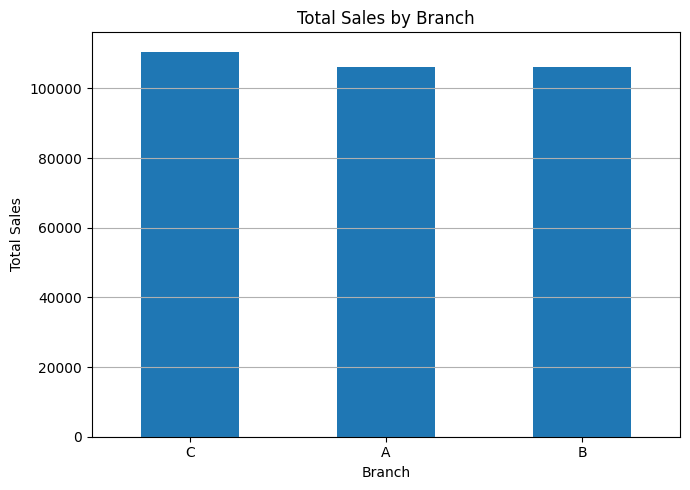

In [97]:
plt.figure(figsize=(7, 5))

branch_sales.plot(kind='bar')
plt.title('Total Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [98]:
# Which payment method is most commonly used by customers?

payment_count = df['Payment'].value_counts()
print(payment_count)


Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


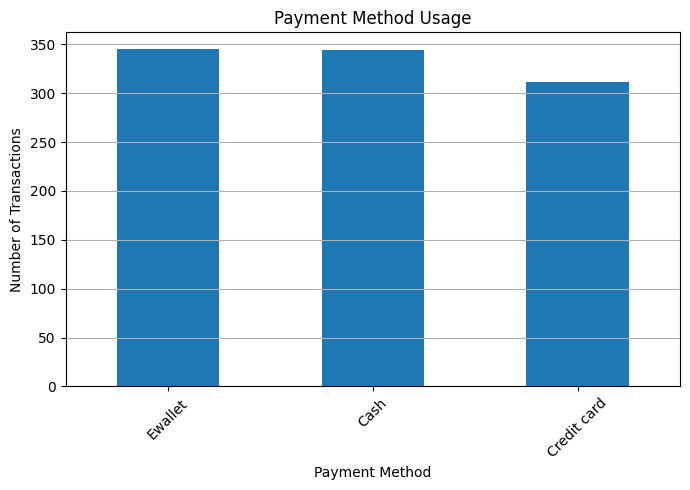

In [99]:
plt.figure(figsize=(7, 5))

payment_count.plot(kind='bar')

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [100]:
# Do members generate more sales than normal customers?

customer_sales = df.groupby('Customer type')['Total'].sum().sort_values(ascending=False)
print(customer_sales)

Customer type
Member    164223.444
Normal    158743.305
Name: Total, dtype: float64


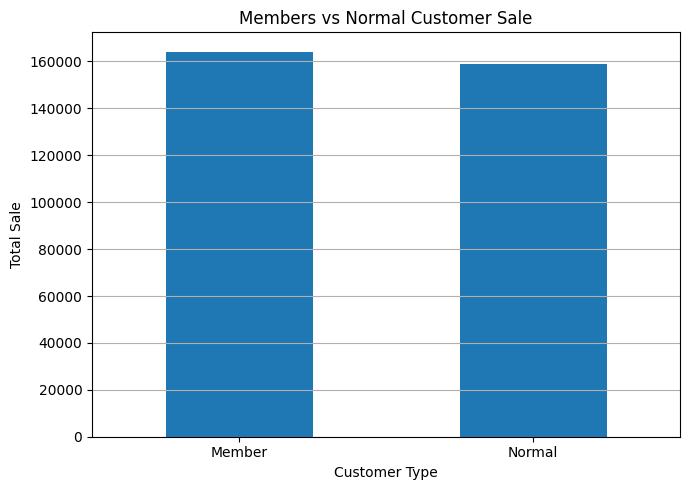

In [101]:
plt.figure(figsize=(7, 5))

customer_sales.plot(kind='bar')

plt.title("Members vs Normal Customer Sale")
plt.xlabel('Customer Type')
plt.ylabel('Total Sale')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [102]:
customer_count = df['Customer type'].value_counts()

print(customer_count)

Customer type
Member    501
Normal    499
Name: count, dtype: int64


In [103]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating,Months,Month_name,Day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,1,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6,3,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,3,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,1,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2,February,Friday


In [104]:
# Does the category with the highest sales also sell the highest quantity?

quantity_by_category = df.groupby('Product line')['Quantity'].sum().sort_values(ascending=False)
print(quantity_by_category)

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64


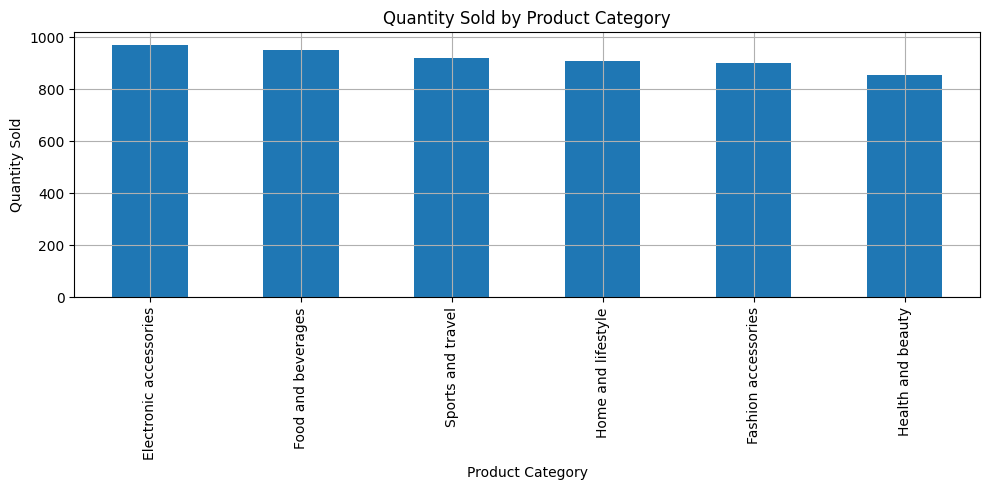

In [105]:
plt.figure(figsize=(10, 5))

quantity_by_category.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()
plt.show()

In [106]:
profit_by_category = df.groupby('Product line')['Gross income'].sum().sort_values(ascending=False)
print(profit_by_category)

Product line
Food and beverages        2673.5640
Sports and travel         2624.8965
Electronic accessories    2587.5015
Fashion accessories       2585.9950
Home and lifestyle        2564.8530
Health and beauty         2342.5590
Name: Gross income, dtype: float64


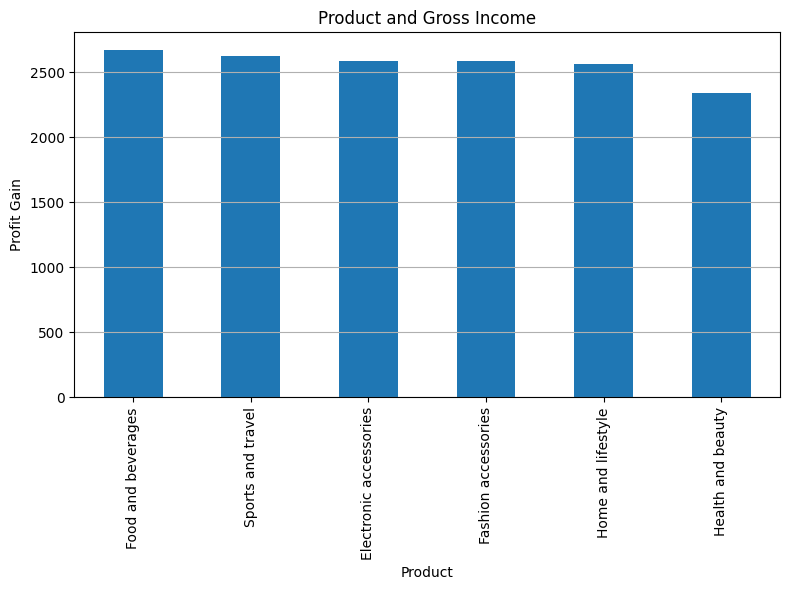

In [107]:
plt.figure(figsize=(8, 6))

profit_by_category.plot(kind='bar')

plt.title('Product and Gross Income')
plt.xlabel('Product')
plt.ylabel('Profit Gain')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [108]:
# Sales vs Quantity comparison

comparison = df.groupby('Product line').agg(
    Total_Sales=('Total', 'sum'),
    Quantity_Sold=('Quantity', 'sum')
).sort_values('Total_Sales', ascending=False)

print(comparison)

                        Total_Sales  Quantity_Sold
Product line                                      
Food and beverages       56144.8440            952
Sports and travel        55122.8265            920
Electronic accessories   54337.5315            971
Fashion accessories      54305.8950            902
Home and lifestyle       53861.9130            911
Health and beauty        49193.7390            854


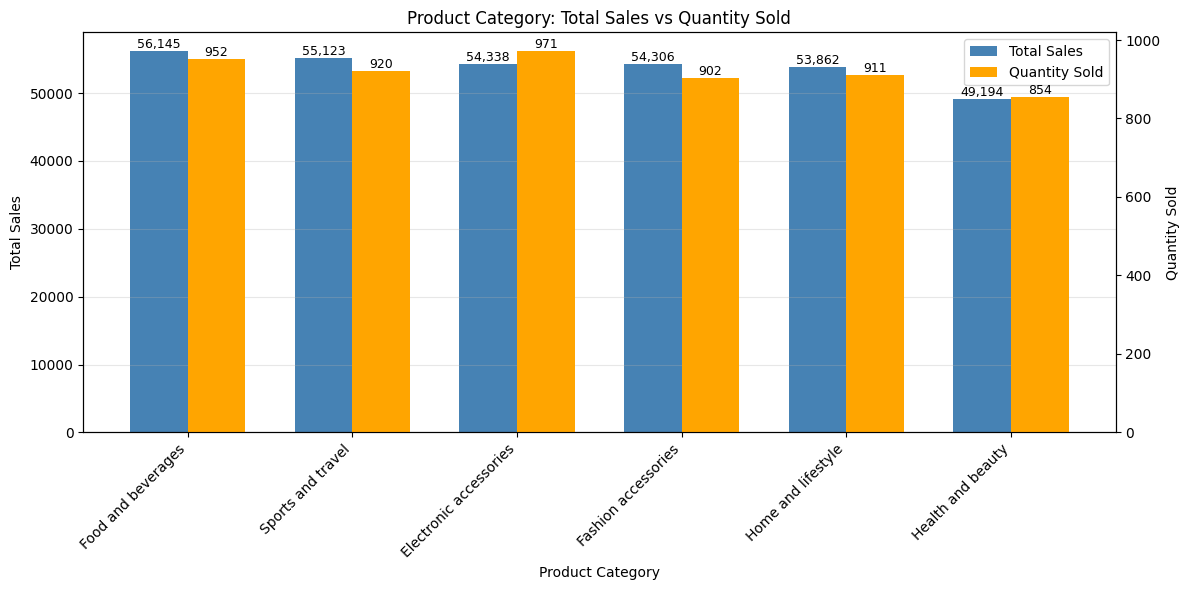

In [109]:

# Create comparison chart

categories = comparison.index
sales = comparison['Total_Sales']
quantity = comparison['Quantity_Sold']

x = np.arange(len(categories))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

# Sales bars
bars1 = ax1.bar(
    x - width/2,
    sales,
    width,
    label='Total Sales',
    color='steelblue'    
)

ax1.set_xlabel('Product Category')
ax1.set_ylabel('Total Sales')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right')

# Quantity bars on second axis
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    quantity,
    width,
    label='Quantity Sold',
    color='orange'
)

ax2.set_ylabel('Quantity Sold')

# Title
plt.title('Product Category: Total Sales vs Quantity Sold')

# Add values on Sales bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add values on Quantity bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper right'
)

ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [110]:
# Do members actually spend more per transaction?

avg_order_customer = df.groupby('Customer type')['Total'].mean()
print(avg_order_customer)

Customer type
Member    327.791305
Normal    318.122856
Name: Total, dtype: float64


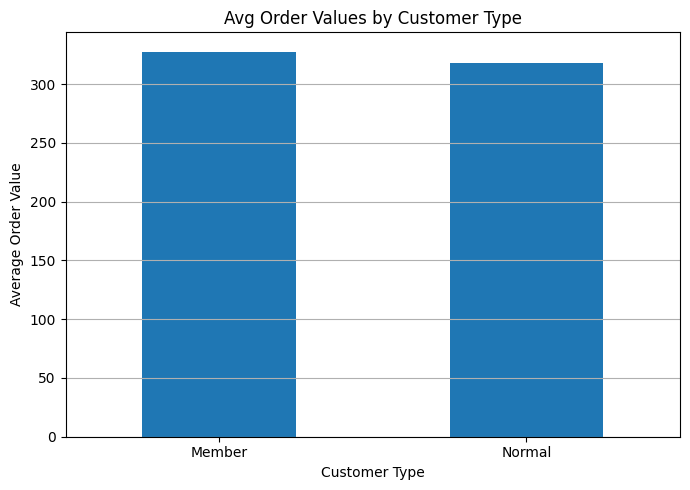

In [111]:
plt.figure(figsize=(7, 5))

avg_order_customer.plot(kind='bar')
plt.title('Avg Order Values by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Order Value')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## 4. SQL Analysis

The cleaned dataset is loaded into SQLite and analyzed using SQL queries to answer key business questions.

In [112]:
conn = sqlite3.connect('supermarket_sales.db')

df.to_sql('sales', conn, if_exists='replace', index=False)

print('Data Successfully Loaded into SQL')

Data Successfully Loaded into SQL


In [113]:
query = """ 
    SELECT * FROM SALES LIMIT 5;
"""
pd.read_sql(query, conn)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,Cost of goods sold,Gross margin percentage,Gross income,Customer stratification rating,Months,Month_name,Day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05 00:00:00,13:08:00.000000,Ewallet,522.83,4.761905,26.1415,9.1,1,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08 00:00:00,10:29:00.000000,Cash,76.40,4.761905,3.8200,9.6,3,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03 00:00:00,13:23:00.000000,Credit card,324.31,4.761905,16.2155,7.4,3,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27 00:00:00,20:33:00.000000,Ewallet,465.76,4.761905,23.2880,8.4,1,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08 00:00:00,10:37:00.000000,Ewallet,604.17,4.761905,30.2085,5.3,2,February,Friday


In [114]:
query = """ 
    SELECT SUM(TOTAL) as Total_sales
    FROM sales;
"""
pd.read_sql(query, conn)

,Total_sales
0,322966.749


In [115]:
query = """ 
    SELECT SUM(Quantity) as Total_Quantity
    FROM sales 
"""
pd.read_sql(query, conn)

,Total_Quantity
0,5510


In [116]:
query = """ 
    SELECT 
        "Product line", ROUND(SUM(Total), 2) as Total_Sales
        FROM sales
    GROUP BY "Product line"
    ORDER BY Total_sales Desc
"""
pd.read_sql(query, conn)

,Product line,Total_Sales
0,Food and beverages,56144.84
1,Sports and travel,55122.83
2,Electronic accessories,54337.53
3,Fashion accessories,54305.89
4,Home and lifestyle,53861.91
5,Health and beauty,49193.74


In [117]:
query = """ 
    SELECT Branch, ROUND(SUM(Total), 2) as Total_sales
    FROM sales 
    GROUP BY Branch
    ORDER BY Total_sales Desc
"""
pd.read_sql(query, conn)

,Branch,Total_sales
0,C,110568.71
1,A,106200.37
2,B,106197.67


In [118]:
query = """ 
    SELECT Payment, COUNT(*) as Transactions
    FROM sales GROUP BY Payment
    ORDER By Transactions DESC
"""
pd.read_sql(query, conn)

,Payment,Transactions
0,Ewallet,345
1,Cash,344
2,Credit card,311


In [119]:
query = """ 
    SELECT "Customer type", ROUND(SUM(Total)) as Total_sales, COUNT(*) as Transactions
    FROM sales
    GROUP BY "Customer type"
    ORDER BY Total_sales DESc
"""
pd.read_sql(query, conn)

,Customer type,Total_sales,Transactions
0,Member,164223.0,501
1,Normal,158743.0,499


In [120]:
query = """
SELECT 
    CASE SUBSTR(Date, 6, 2)
        WHEN '01' THEN 'January'
        WHEN '02' THEN 'February'
        WHEN '03' THEN 'March'
    END AS Month,
    ROUND(SUM(Total), 2) AS Total_Sales
FROM sales
GROUP BY SUBSTR(Date, 6, 2)
ORDER BY SUBSTR(Date, 6, 2);
"""

pd.read_sql(query, conn)

,Month,Total_Sales
0,January,116291.87
1,February,97219.37
2,March,109455.51


In [121]:
query = """
SELECT 
    "Product line",
    ROUND(SUM("Gross income"), 2) AS Gross_Income
FROM sales
GROUP BY "Product line"
ORDER BY Gross_Income DESC;
"""

pd.read_sql(query, conn)

,Product line,Gross_Income
0,Food and beverages,2673.56
1,Sports and travel,2624.90
2,Electronic accessories,2587.50
3,Fashion accessories,2585.99
4,Home and lifestyle,2564.85
5,Health and beauty,2342.56


In [122]:
query = """
SELECT 
    ROUND(AVG(Total), 2) AS Average_Order_Value
FROM sales;
"""

pd.read_sql(query, conn)

,Average_Order_Value
0,322.97


In [123]:
query = """
SELECT 
    "Invoice ID",
    "Product line",
    Quantity,
    ROUND(Total, 2) AS Total
FROM sales
ORDER BY Total DESC
LIMIT 5;
"""

pd.read_sql(query, conn)

,Invoice ID,Product line,Quantity,Total
0,860-79-0874,Fashion accessories,10,1042.65
1,687-47-8271,Fashion accessories,10,1039.29
2,283-26-5248,Food and beverages,10,1034.46
3,751-41-9720,Home and lifestyle,10,1023.75
4,303-96-2227,Home and lifestyle,10,1022.49


## 5. Business Insights & Conclusion

## 5. Business Insights & Conclusion

### Key Business Insights

- **Overall Performance:** The supermarket generated total sales of **322,966.75** across **1,000 transactions**, with **5,510 units** sold.

- **Monthly Sales:** **January** recorded the highest sales at **116,291.87**, followed by March at **109,455.51** and February at **97,219.37**.

- **Branch Performance:** **Branch C** generated the highest sales of **110,568.71**, making it the best-performing branch.

- **Product Performance:** **Food and Beverages** was the highest-selling product line with sales of approximately **56,144.84**.

- **Customer Behavior:** Member customers generated slightly higher sales than normal customers, indicating that membership contributes positively to sales.

- **Payment Preference:** **E-wallet** was the most frequently used payment method, followed closely by Cash and Credit Card.

- **Profitability:** Food and Beverages generated the highest gross income among the product lines.

- **Average Order Value:** The average transaction value was approximately **322.97**.

### Conclusion

The analysis shows that sales performance is relatively balanced across branches and product lines, while customer membership and digital payment methods play an important role in purchasing behavior. January was the strongest month, and Food and Beverages was the leading product category.

The analysis was performed using **Python, Pandas, Matplotlib, Seaborn, and SQLite**, with the results further presented through an interactive **Power BI dashboard**.